In [2]:
# Alex Medina
# AST 5765 
# Final Project
# 8 November 2025

In [3]:
##### IMPORTS
import os
import disk as d
import numpy as np
import gaussian as g
import astropy.io.fits as fits
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip

In [4]:
print('Problem 1) \n')
print('Completed on log. \n')

Problem 1) 

Completed on log. 



In [5]:
print('Problem 2) \n')
print('Completed on log. \n')

Problem 2) 

Completed on log. 



In [6]:
print('Problem 3 \n')

Problem 3 



In [7]:
##### VARIABLES
datadir = 'data/'
fext    = '.fits'

datafiles = []

for filename in os.listdir(datadir): # for creation of another variable
    if filename.startswith('SPITZER'):
        file =filename.split(fext)[0]
        datafiles.append(file)

datafiles = sorted(datafiles)
nfiles    = len(datafiles)

# Column indices in the photometry array
setnum_col     = 0  # number of SPITZER file
fnumber_col    = 1  # local frame number (within SPITZER file)
glob_index_col = 2  # global frame number (over all files)
MJD_col        = 3  # mid-time of the frame (MJD, days)
medbkg         = 4  # background value
ycenter        = 5  # y center fit
xcenter        = 6  # x center fit
width          = 7
flux_col       = 8
sky_col        = 9
bad_col        = 10

In [8]:
print(datadir)

data/


In [9]:
print('Problem 4 \n')

Problem 4 



In [10]:
# ROUTINE for files

# a) Read first block for relevant information
infofile   = fits.getdata(datadir + datafiles[0] + fext)
nf, nx, ny = infofile.shape
print(f'The number of frames per file: {nf} frames')

# b) Datacube and photometry array to save important numbers
totframes  = nfiles * nf
datacube   = np.zeros((totframes, nx, ny))
print(f'The shape of the datacube: {datacube.shape}')

nparams   = 11  # parameter indexes listed in variables
photometry  = np.zeros((totframes, nparams))
print(f'The shape of the photometry array: {photometry.shape}')

# c) Main routine
def read_sets(startset, endset, datacube, photarr):
    """
    Loop over SPITZER frames starting at a given global subarray set number (frame index) and ending at another (inclusive).

    Parameters
    startset : int
        global frame number from which to begin allocating data
    endset : int
        global frame number from which to end allocating data
    datacube : np.array
        empty datacube to store data
    photarr : np.array
        array to store photometry numbers
    
    Results
    completed datacube and updated photometry array
    """
    # Start and end set
    print(f"Reading frames {startset} through {endset}.")

    # Cache the last file it doesn't read same file 64 times
    current_index = None
    datablock     = None
    hdr           = None

    for global_frame_index in range(startset, endset + 1):
        # Find SPITZER file where global frame exists
        # i.e., 187 // 64 = 2, means global frame 187 is in SPITZER
        # file 3 because index 2, also file 3 has frames (128 through 191)
        file_index = global_frame_index // nf

        # Within the SPITZER file, the local file number
        # i.e., 187 % 64, is 187.62 is 2 with remainder is 59,
        # so it's the 60th frame in in the SPITZER file
        local_frame_index = global_frame_index % nf

        # Load new file when file_index changes
        if file_index != current_index:
            current_index = file_index
            # i) read data and header
            datablock, hdr = fits.getdata(datadir + datafiles[file_index] + fext, header=True)

            # Print every 10th file (not frame) we touch in this range
            # Which means we only get 2 print statments for whole set
            if (file_index - (startset // nf)) % 10 == 0:
                print(f'{datafiles[file_index]} : DATE_OBS = {hdr["DATE_OBS"]}')

            framtime  = hdr['FRAMTIME']  # interval between frames in a set
            exptime   = hdr['EXPTIME']   # duration of one exposure (s)
            mjd_start = hdr['MJD_OBS']   # start of first frame (days)

            # Take half exptime and add to a time keyword(mjd_start) to get midtime of first frame
            t0 = mjd_start + (0.5 * exptime) / 86400  # days

        # ii) Put science data into the 3D datacube
        datacube[global_frame_index, :, :] = datablock[local_frame_index, :, :]

        # iii) Subsequent images separated by framtime after t0
        mid_time = t0 + local_frame_index * ( framtime / 86400 )  # days

        # Filling photometry array
        photarr[global_frame_index, setnum_col]     = file_index
        photarr[global_frame_index, fnumber_col]    = local_frame_index
        photarr[global_frame_index, glob_index_col] = global_frame_index
        photarr[global_frame_index, MJD_col]        = mid_time

    return datacube, photarr

The number of frames per file: 64 frames
The shape of the datacube: (1536, 32, 32)
The shape of the photometry array: (1536, 11)


In [11]:
print('Problem 5 \n')

Problem 5 



Reading frames 187 through 686.
SPITZER_I4_20674048_0102_0000_2_bcd : DATE_OBS = 2006-10-28T23:55:32.373


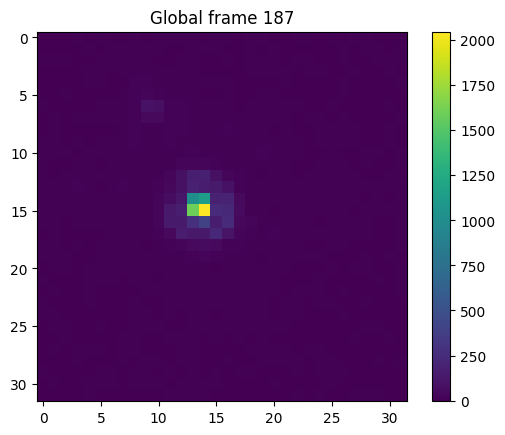

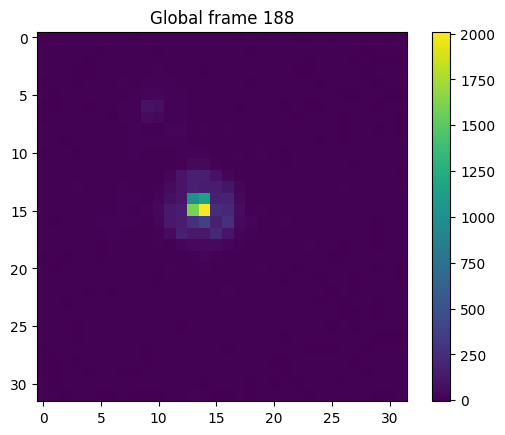

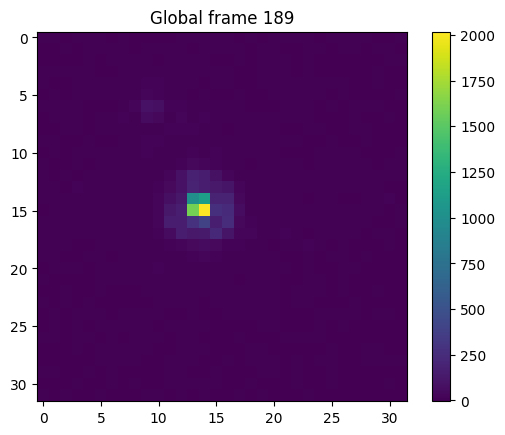

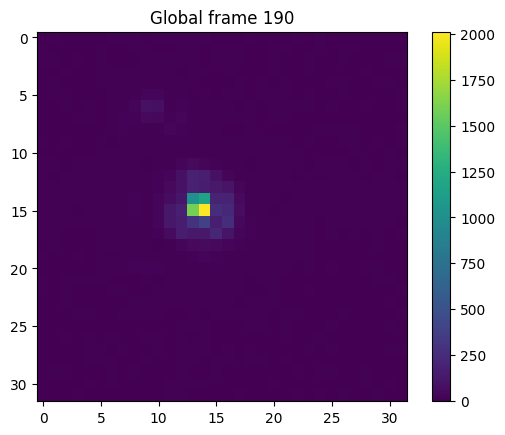

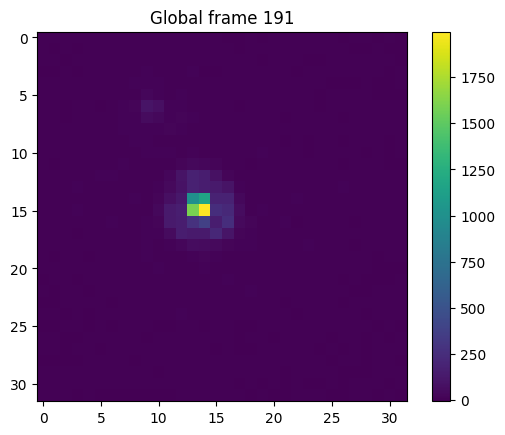

Reading frames 0 through 1535.
SPITZER_I4_20674048_0100_0000_2_bcd : DATE_OBS = 2006-10-28T23:54:37.795
SPITZER_I4_20674048_0110_0000_2_bcd : DATE_OBS = 2006-10-28T23:59:11.669
SPITZER_I4_20674048_0120_0000_2_bcd : DATE_OBS = 2006-10-29T00:03:45.685


In [12]:
# Run the function, starting at subarray set 0187 and ending at 0686 (inclusive)

startset5 = 187
endset5   = 686
datacube5, photometry5 = read_sets(startset5, endset5, datacube, photometry)

# Looking at first few frames
# Only running when this true
inspect_p5 = True

if inspect_p5:
    for i in range(startset5, startset5 + 5):
        plt.figure()
        plt.imshow(datacube5[i, :, :])
        plt.colorbar()
        plt.title(f'Global frame {i}')
        plt.show()

    # Check that you do not have blank frames at the end of your data array
    #tail_means = datacube[-:].mean(axis=(1, 2))
    #print("Mean of last 10 frames in datacube:", tail_means)

    #blank_frames = np.where(np.all(datacube == 0.0, axis=(1, 2)))[0]
    #print("Indices of completely blank frames (if any):", blank_frames[-20:])

# For the rest of the assignment, using all frames
startset = 0
endset   = 1535
datacube, photometry = read_sets(startset, endset, datacube, photometry)

In [13]:
print('Problem 6 \n')

Problem 6 



In [14]:
# Boolean mask array thats the same shape as data array
# True = good pixel, False = bad pixel
# Initialize to true using np.ones
mask = np.ones_like(datacube, dtype=bool)

In [15]:
print('Problem 7 \n')

Problem 7 



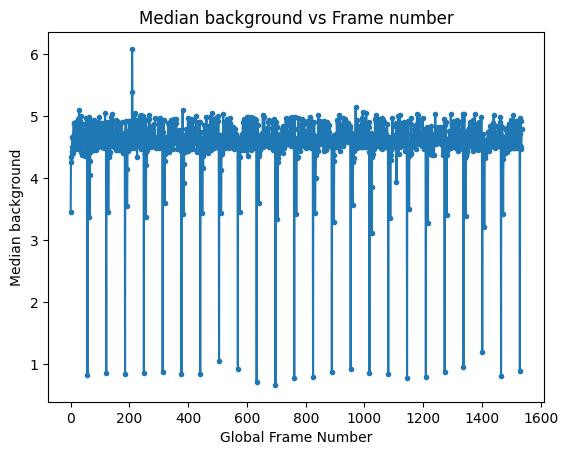

In [16]:
# Median value in each frame
# I suppose because from inspection most of the image is sky

for i in range(totframes):
    med = np.median(datacube[i, :, :])
    photometry[i, medbkg] = med
    datacube[i, :, :]    -= med # subtract median

# Background vs frame number
plt.figure()
plt.plot(photometry[:, medbkg], marker='.')
plt.xlabel("Global Frame Number")
plt.ylabel("Median background")
plt.title("Median background vs Frame number")
plt.show()


In [17]:
print('Problem 8 \n')

Problem 8 



In [18]:
# Sigma-rejection routine

def sigma_reject(data, sigma, iters):
    """
    Sigma-rejection

    Parameters
    data : np.array
        data array
    sigma : int or float
        sigma
    iters : int or float
        number of iterations
    
    Returns
        Boolean array where True = good pixel, False = bad pixel.
    """
    clipped = sigma_clip(data, sigma=sigma, maxiters=iters, masked=True)
    # clipped values are returned as True, but those are the bad
    # so the good mask is the non-clipped values
    good_mask = ~clipped.mask
    return np.asarray(good_mask)


In [19]:
print('Problem 9 \n')

Problem 9 



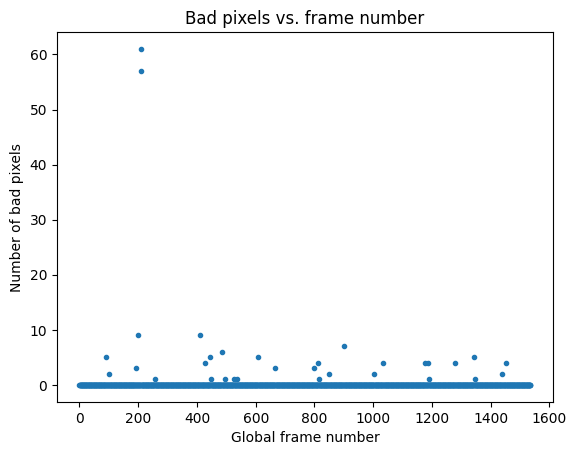

In [20]:
# Find bad pixels

# First loop steps by jumps of 64
for f0 in range(0, totframes, nf):
    f63 = f0 + nf # end index (exclusive) for this block
    # Second and third loops over y and x
    for y in range(ny):
        for x in range(nx):
            # Extract each set of 64 pixels (1 from each frame) at same y, x
            extract = datacube[f0:f63, y, x]

            # Sigma reject on each set
            good = sigma_reject(extract, 5.0, 2)

            # Insert resulting boolean into mak array
            mask[f0:f63, y, x] &= good

# From problem 8, all bad pixels not in current mask are flagged as 0
# To not account for bad pixels
datacube[~mask] = 0

# Bad pixels vs frame number
bad_counts = (~mask).sum(axis=(1, 2))

plt.figure()
plt.plot(np.arange(totframes), bad_counts, marker='.', linestyle='none')
plt.xlabel("Global frame number")
plt.ylabel("Number of bad pixels")
plt.title("Bad pixels vs. frame number")
plt.show()


In [21]:
print('Problem 10 \n')

Problem 10 



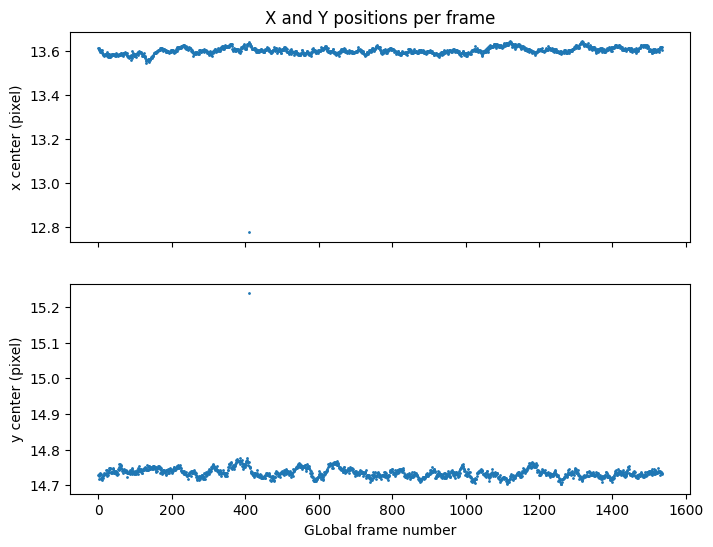

In [22]:
# Approximate location of center of star routine

def fitcenter(frame, yguess, xguess, subz):
    """
    Fit 2D Gaussian around guess

    Parameters
    
    center : (yguess, xguess)
    """

    # Subarray
    yg, xg = int(yguess), int(xguess)

    ytop = yg + subz + 1
    ybot = yg - subz
    xtop = xg + subz + 1
    xbot = xg - subz

    sub = frame[ybot:ytop, xbot:xtop].copy()
    sub -= np.median(sub) # median sub

    # Fitting relative to subarr (width tuple) (center tuple) (height)
    guess = ((2.0, 2.0), (yg - ybot, xg - xbot), np.max(sub))

    # Gaussian fit
    fw, fc, fh, fe = g.fitgaussian(sub, guess=guess)

    sigma_avg = float((fw[0] + fw[1]) / 2.0)

    # Fitting back to original coords
    cy, cx = float(fc[0] + ybot), float(fc[1] + xbot)

    return cy, cx, sigma_avg
    
# For the first frame, viually its about y, x = 15, 14
frame0 = datacube[0, :, :]
y0, x0 = 15, 14
cy0, cx0, sigma = fitcenter(frame0, y0, x0, 6) # say subz = 6 for now
photometry[0, ycenter] = cy0
photometry[0, xcenter] = cx0

# Looping over all imtages, using previous fitted position as guess
for i in range(1, totframes):
    framei = datacube[i, :, :]
    yi, xi = photometry[i-1, ycenter], photometry[i-1, xcenter]
    cyi, cxi, sigma_i = fitcenter(framei, yi, xi, 6)
    photometry[i, ycenter] = cyi
    photometry[i, xcenter] = cxi
    photometry[i, width  ] = sigma_i

# Plot x and y position vs the frame number
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax1.plot(photometry[:, xcenter], '.', ms=2)
ax1.set_ylabel('x center (pixel)')
ax1.set_title('X and Y positions per frame')
ax2.plot(photometry[:, ycenter], '.', ms=2)
ax2.set_ylabel('y center (pixel)')
ax2.set_xlabel('GLobal frame number')
plt.show()

In [23]:
print('Problem 11 \n')

Problem 11 



In [24]:
# Median image over all data
median_image = np.median(datacube, axis=0)

# Main star for offset from graph is about (y, x) = (14.7, 13.6)
ygstar, xgstar = 14.7, 13.6
cystar, cxstar, _ = fitcenter(median_image, ygstar, xgstar, subz=6)

# Visually, from the images in problem 5, it's up to the left of the star
# At about x = 9, y = 6
ygfaint, xgfaint = 6, 9
cyfaint, cxfaint, _ = fitcenter(median_image, ygfaint, xgfaint, subz=4)

# Offset from median image
yoff = cyfaint - cystar
xoff = cxfaint - cxstar

print(f"Companion offset from main star: change in y = {yoff} pixels, change in x = {xoff} pixels")

# Mask the companion star in each frame
r_mask = 4  # radius of disk to mask around the companion
yy, xx = np.indices((ny, nx)) # Coordinate grid

for i in range(totframes):
    # Star center for this frame
    cy = photometry[i, ycenter]
    cx = photometry[i, xcenter]

    # Apply offset for companion center
    cy_comp = cy + yoff
    cx_comp = cx + xoff

    # Mask disk to remove companion star
    dist = (yy - cy_comp)**2 + (xx - cx_comp)**2

    # Mark pixels within radius as bad (False)
    mask[i, dist <= r_mask**2] = False

Companion offset from main star: change in y = -8.539203091233206 pixels, change in x = -4.191255082214411 pixels


In [25]:
print('Problem 12 \n')

Problem 12 



In [26]:
# Aperture photometry using HW 10

def aperture_photometry(data, mask, photrad, skyin, skyout, center):
    """
    Parameters
    ----------
    data : 2D ndarray
        Image for a single frame.
    mask : 2D ndarray of bool
        True = good pixel, False = bad pixel.
    photrad : float
        Radius of the photometry aperture (pixels).
    skyin : float
        Inner radius of the sky annulus (pixels).
    skyout : float
        Outer radius of the sky annulus (pixels).
    center : tuple (cy, cx)
        Center of the star in pixel coordinates (y, x).

    Returns
    -------
    arr : 1D ndarray
        [stellar_flux, average_sky, n_bad_in_aperture]
    """
    # No need for a subimage
    
    # a) use disk to make mask of sky nnulus
    skymask = d.disk( skyout, center, data.shape)^d.disk( skyin, center, data.shape ) 

    # b) apply bad-pixel mask to sky annulus (only good sky pixels)
    good_sky = skymask & mask

    # c) average sky level using only good sky pixels
    skyavg = np.sum( good_sky * data ) / np.sum( good_sky )

    # d) subtract sky from image
    data_sky_sub = data - skyavg

    # e) aperture mask (do NOT apply bad-pixel mask here)
    apmask = d.disk(photrad, center, data.shape)

    # f) total stellar flux in the aperture (sky already subtracted)
    flux = np.sum( apmask * data_sky_sub )

    # g) number of bad pixels in the aperture, ~mask is bad pixels
    nbadapt = np.sum(apmask & ~mask)

    return np.array([flux, skyavg, nbadapt])

In [27]:
print('Problem 13 \n')

Problem 13 



In [28]:
# Loop over all frames and update table
# Store aperture counts(flux), average sky, and number of bad pixels

# Loop
for i in range(totframes):
    # Fitted width
    sigma = np.mean(photometry[i, width])
    photrad  = 3.0 * sigma 
    skyin    = 5.0 * sigma
    skyout   = 8.0 * sigma
    
    frame = datacube[i]
    fmask  = mask[i]

    cy = photometry[i, ycenter]
    cx = photometry[i, xcenter]

    photarr = aperture_photometry(frame, fmask, photrad, skyin, skyout, (cy, cx))
    
    photometry[i, flux_col] = photarr[0]
    photometry[i, sky_col]  = photarr[1]
    photometry[i, bad_col]  = photarr[2]

c:\Users\Alex\Desktop\AST5765\lectures_git\final\disk.py:64: RuntimeWarning: divide by zero encountered in divide
  return np.sum(((idisk - cctr)/rr)**2, axis=0) <= 1.
C:\Users\Alex\AppData\Local\Temp\ipykernel_22632\3359367847.py:34: RuntimeWarning: invalid value encountered in scalar divide
  skyavg = np.sum( good_sky * data ) / np.sum( good_sky )


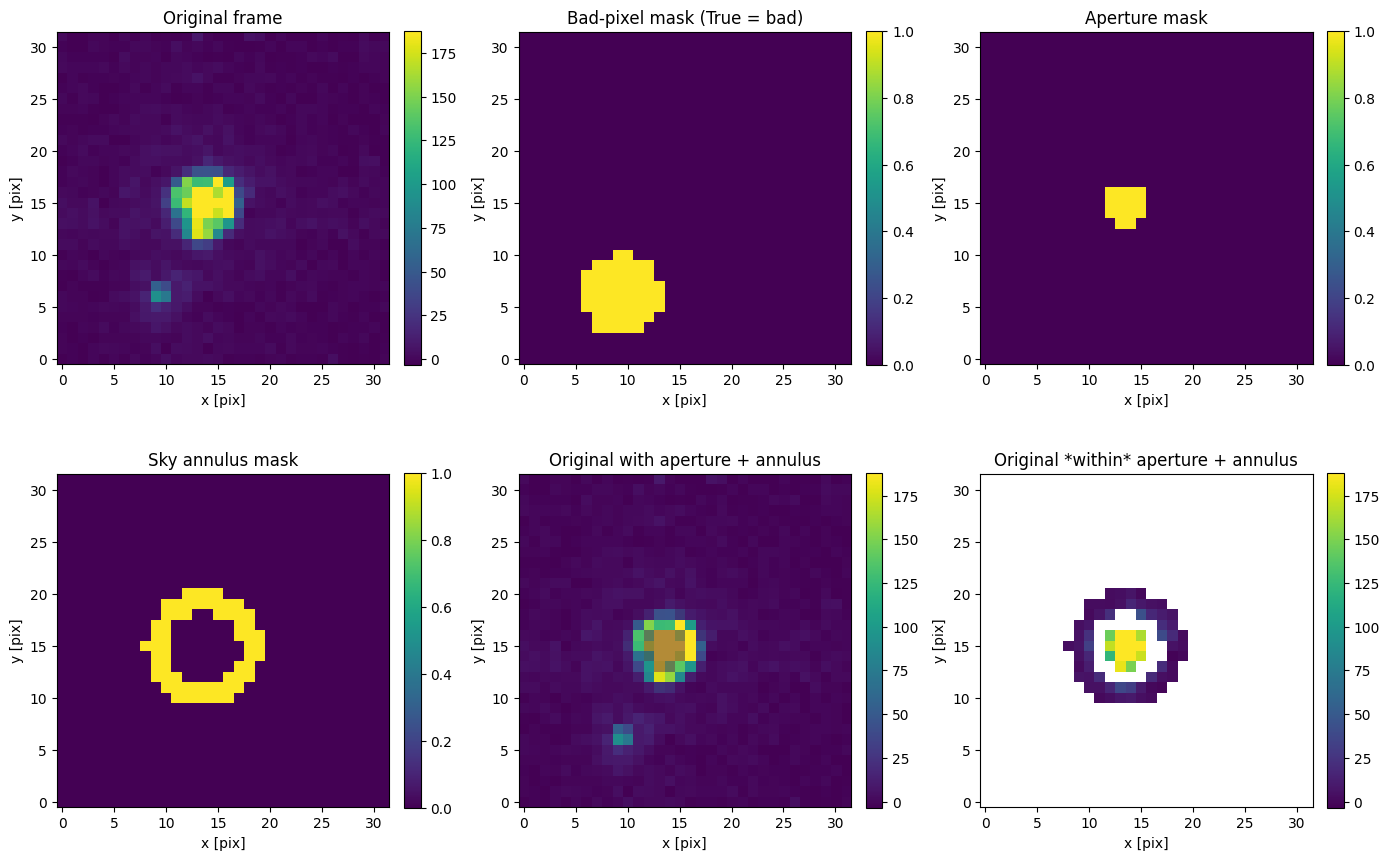

In [29]:
# For consistency, to make sure my code is doing good
# Plotting outputs

i_test = 1000

frame = datacube[i_test]
fmask = mask[i_test]

cy = photometry[i_test, ycenter]
cx = photometry[i_test, xcenter]
center = (cy, cx)

# Build masks
apmask   = d.disk(photrad, center, frame.shape)
skymask  = d.disk(skyout, center, frame.shape) ^ d.disk(skyin, center, frame.shape)
badmask  = ~fmask  # True = bad pixel

# Display scaling
vmin, vmax = np.percentile(frame, (5, 99))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
(ax0, ax1, ax2), (ax3, ax4, ax5) = axes

# 1) Original frame
im0 = ax0.imshow(frame, origin="lower", vmin=vmin, vmax=vmax)
ax0.set_title("Original frame")
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

# 2) Bad pixel mask (white = bad)
im1 = ax1.imshow(badmask, origin="lower")
ax1.set_title("Bad-pixel mask (True = bad)")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 3) Aperture mask
im2 = ax2.imshow(apmask, origin="lower")
ax2.set_title("Aperture mask")
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 4) Annulus (sky) mask
im3 = ax3.imshow(skymask, origin="lower")
ax3.set_title("Sky annulus mask")
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# 5) Original + aperture + annulus overlay
im4 = ax4.imshow(frame, origin="lower", vmin=vmin, vmax=vmax)
# aperture overlay
ap_overlay = np.ma.masked_where(~apmask, apmask)
ax4.imshow(ap_overlay, origin="lower", alpha=0.4)
# annulus overlay
sky_overlay = np.ma.masked_where(~skymask, skymask)
ax4.imshow(sky_overlay, origin="lower", alpha=0.3)
ax4.set_title("Original with aperture + annulus")
fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# 6) Optional: aperture & annulus applied to original (only those pixels shown)
masked_frame = np.ma.masked_where(~(apmask | skymask), frame)
im5 = ax5.imshow(masked_frame, origin="lower", vmin=vmin, vmax=vmax)
ax5.set_title("Original *within* aperture + annulus")
fig.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xlabel("x [pix]")
    ax.set_ylabel("y [pix]")

plt.tight_layout()
plt.show()


In [30]:
print('Problem 14 \n')

Problem 14 



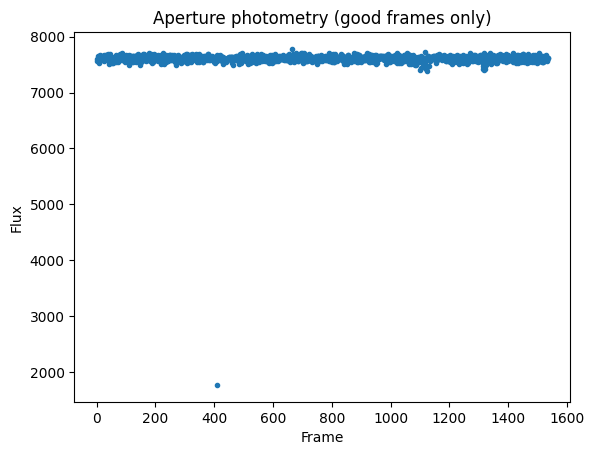

In [31]:
# Check photometry

# Good frames with no bad pixels in them
# If good frame, then no bad pixels in bad_col
good = photometry[:, bad_col] == 0

good_flux = photometry[good, flux_col]
frames    = np.arange(totframes)[good]

plt.figure()
plt.plot(frames, good_flux, marker='.', linestyle='none')
plt.xlabel("Frame")
plt.ylabel("Flux")
plt.title("Aperture photometry (good frames only)")
plt.show()

In [34]:
# There doesn't appear to be an obvious transit, but there are distinwct outliers


# For frames with a high background
good_sky  = photometry[good, sky_col]
sky_med = np.median(good_sky)
sky_std = np.std(good_sky)
high_sky = (photometry[:, sky_col] > sky_med + 5 * sky_std) & good
# Set bad_col to -1
photometry[high_sky, bad_col] = -1  # very high background

# FOr frames with large star motion
y_good    = photometry[good, ycenter]
x_good    = photometry[good, xcenter]

y_med = np.median(photometry[good, ycenter])
x_med = np.median(photometry[good, xcenter])

dy = photometry[:, ycenter] - y_med
dx = photometry[:, xcenter] - x_med
dr = np.sqrt(dx**2 + dy**2) # error propagation

large_motion = (dr > 0.5) & good
photometry[large_motion, bad_col] = -1

# Recompute good frames after
new_good    = photometry[:, bad_col] == 0
nframes_good = np.arange(totframes)[new_good]
nflux_good   = photometry[new_good, flux_col]
nsky_good    = photometry[new_good, sky_col]
ny_good      = photometry[new_good, ycenter]
nx_good      = photometry[new_good, xcenter]
nbad_good    = photometry[new_good, bad_col]

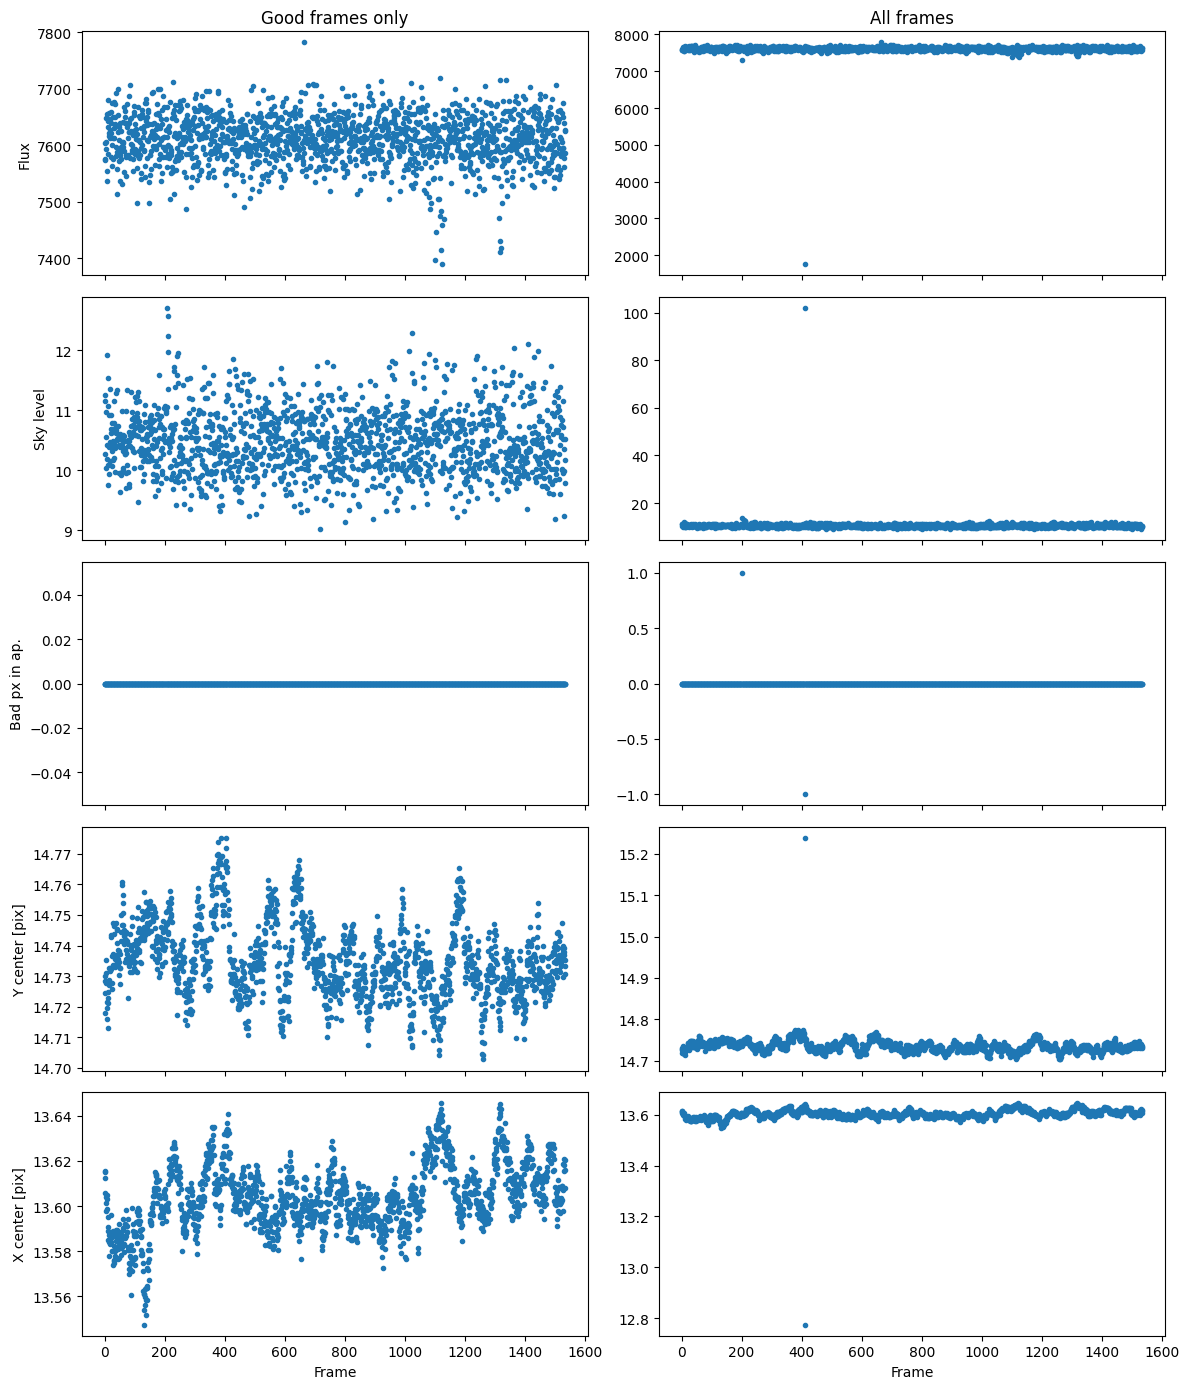

In [36]:
# 1) Flux vs frameimport matplotlib.pyplot as plt
import numpy as np

# --- select good frames ---
good_mask    = photometry[:, bad_col] == 0

frames_all   = np.arange(totframes)
flux_all     = photometry[:, flux_col]
sky_all      = photometry[:, sky_col]
bad_all      = photometry[:, bad_col]
y_all        = photometry[:, ycenter]
x_all        = photometry[:, xcenter]

frames_good  = frames_all[good_mask]
flux_good    = flux_all[good_mask]
sky_good     = sky_all[good_mask]
bad_good     = bad_all[good_mask]
y_good       = y_all[good_mask]
x_good       = x_all[good_mask]

# --- make 5x2 subplot grid ---
fig, axes = plt.subplots(5, 2, figsize=(12, 14), sharex='col')

# Row 0: Flux
axes[0, 0].plot(frames_good, flux_good, 'o', ms=3)
axes[0, 0].set_ylabel("Flux")
axes[0, 0].set_title("Good frames only")

axes[0, 1].plot(frames_all, flux_all, 'o', ms=3)
axes[0, 1].set_title("All frames")

# Row 1: Average sky
axes[1, 0].plot(frames_good, sky_good, 'o', ms=3)
axes[1, 0].set_ylabel("Sky level")

axes[1, 1].plot(frames_all, sky_all, 'o', ms=3)

# Row 2: Bad pixels in aperture
axes[2, 0].plot(frames_good, bad_good, 'o', ms=3)
axes[2, 0].set_ylabel("Bad px in ap.")

axes[2, 1].plot(frames_all, bad_all, 'o', ms=3)

# Row 3: Y centroid
axes[3, 0].plot(frames_good, y_good, 'o', ms=3)
axes[3, 0].set_ylabel("Y center [pix]")

axes[3, 1].plot(frames_all, y_all, 'o', ms=3)

# Row 4: X centroid
axes[4, 0].plot(frames_good, x_good, 'o', ms=3)
axes[4, 0].set_ylabel("X center [pix]")
axes[4, 0].set_xlabel("Frame")

axes[4, 1].plot(frames_all, x_all, 'o', ms=3)
axes[4, 1].set_xlabel("Frame")

plt.tight_layout()
plt.show()

Bad frame indices: [200 410]


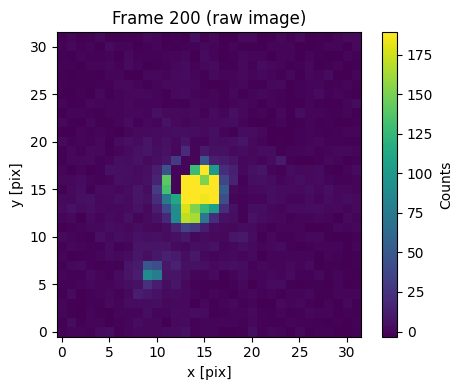

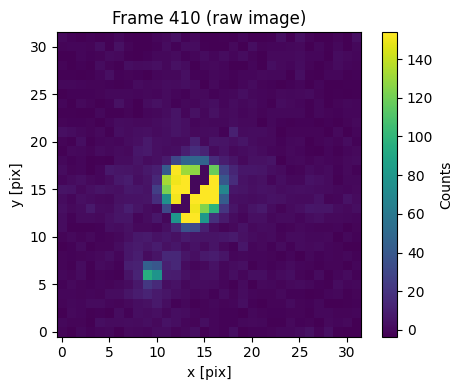

In [39]:
# GOt RID OF THE OUTLIERS 

# Frames with at least one bad pixel in aperture
bad = photometry[:, bad_col] != 0
bad_frames = np.arange(totframes)[bad]
print("Bad frame indices:", bad_frames)

for i in bad_frames:
    frame = datacube[i]

    vmin, vmax = np.percentile(frame, (5, 99))

    plt.figure(figsize=(5, 4))
    plt.imshow(frame, origin="lower", vmin=vmin, vmax=vmax)
    plt.title(f"Frame {i} (raw image)")
    plt.xlabel("x [pix]")
    plt.ylabel("y [pix]")
    plt.colorbar(label="Counts")
    plt.tight_layout()
    plt.show()